# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)
6. [Regression Analysis](#regression-analysis)


. [Correlations](#correlations)


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Overview

The dataset contains 800 observations and 6 variables related to drug treatment and patient recovery. The target variable is recover, while drug represents the treatment. Additional variables include age, SES (socioeconomic status), hospital_rating, and random_noise.

The overall recovery rate is approximately 56.4%, and hospital ratings range from 65.4 to 100.7 with an average of 82.7. The dataset contains both categorical and numerical features and is suitable for analyzing the relationship between treatment and recovery, as well as investigating Simpson’s paradox.

In [12]:
# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/simpson_paradox/medicine.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Describe
print(df.describe())

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())

Number of samples: 800
Number of features: 6
         recover  hospital_rating  random_noise
count  800.00000       800.000000    800.000000
mean     0.56375        82.689377      0.026115
std      0.49623         5.549482      0.966397
min      0.00000        65.393248     -2.635748
25%      0.00000        78.974944     -0.632524
50%      1.00000        82.804853      0.006932
75%      1.00000        86.429733      0.668441
max      1.00000       100.688743      3.109919
Example data:
  drug    age  recover   SES  hospital_rating  random_noise
0  Yes    Old        1  High        90.428932      1.554160
1  Yes    Old        1  High        85.714715      1.563413
2  Yes  Young        0  High        75.507660      1.642673
3  Yes    Old        1   Low        78.399887     -1.111967
4  Yes  Young        0  High        85.429478     -0.328618


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


drug               0
age                0
recover            0
SES                0
hospital_rating    0
random_noise       0
dtype: int64

## Feature Distributions

The feature distributions provide an overview of the dataset characteristics. The variables drug, age, and SES are categorical and appear relatively balanced across their categories. The target variable recover shows a slightly higher proportion of recovered patients (56.4%) than non-recovered patients.

The numerical variable hospital_rating is approximately normally distributed around a mean of 82.7, with most values concentrated between 75 and 90. The random_noise variable is centered around zero and follows a roughly symmetric distribution.


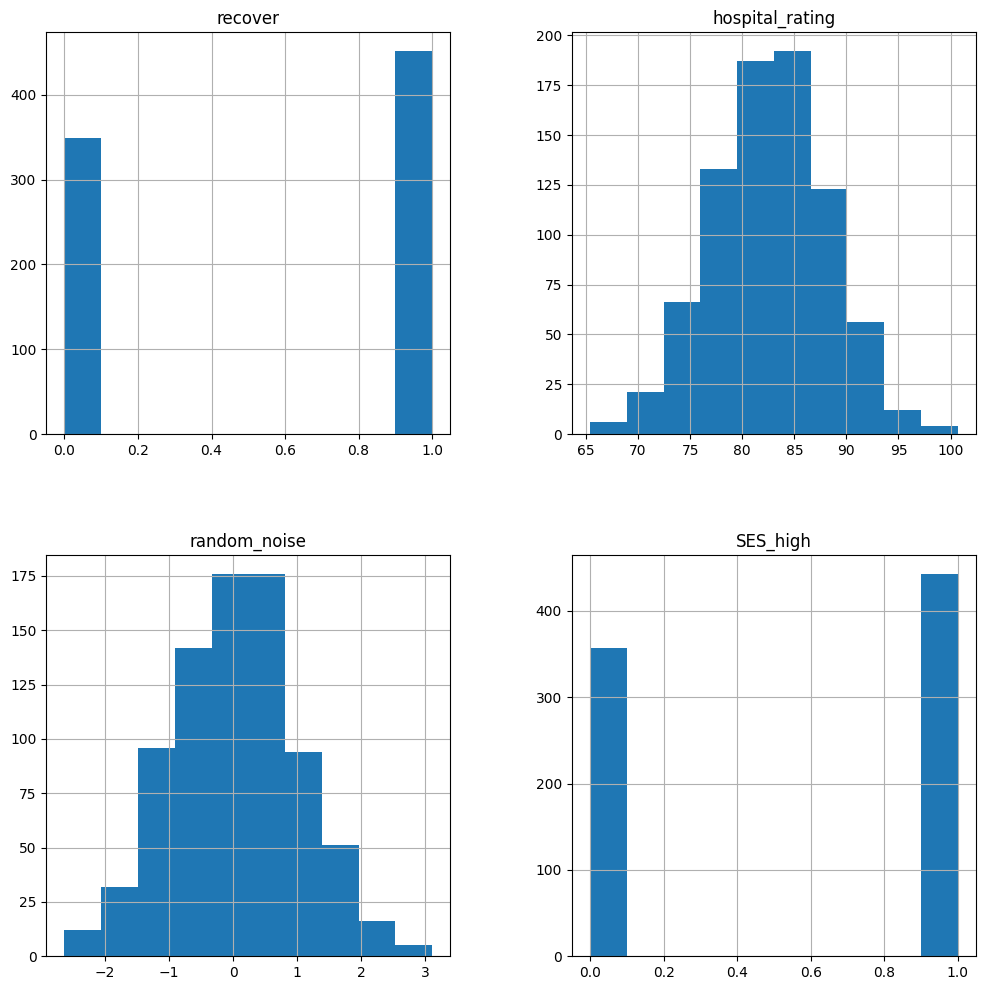

In [19]:
df["SES_high"] = (df["SES"] == "High").astype(int)
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

The dataset shows clear evidence of confounding driven mainly by age. Older patients are much more likely to receive the drug (300 vs. 100 in young group), and age is also strongly related to recovery outcomes.

Because of this imbalance, the aggregated data suggest a positive effect of the drug (61.3% vs. 51.5%), even though within both age groups the drug is associated with lower recovery rates. This indicates a classic Simpson’s paradox, caused by unequal treatment assignment across age groups.

drug   No  Yes
SES           
High  155  288
Low   245  112 

SES
High    0.553047
Low     0.577031
Name: recover, dtype: float64 

drug
No     0.5150
Yes    0.6125
Name: recover, dtype: float64 

SES   drug
High  No      0.458065
      Yes     0.604167
Low   No      0.551020
      Yes     0.633929
Name: recover, dtype: float64 

age    drug
Old    No      0.780000
       Yes     0.716667
Young  No      0.426667
       Yes     0.300000
Name: recover, dtype: float64 

SES   age    drug
High  Old    No      0.750000
             Yes     0.723005
      Young  No      0.356522
             Yes     0.266667
Low   Old    No      0.800000
             Yes     0.701149
      Young  No      0.470270
             Yes     0.400000
Name: recover, dtype: float64 

drug    No  Yes
age            
Old    100  300
Young  300  100 



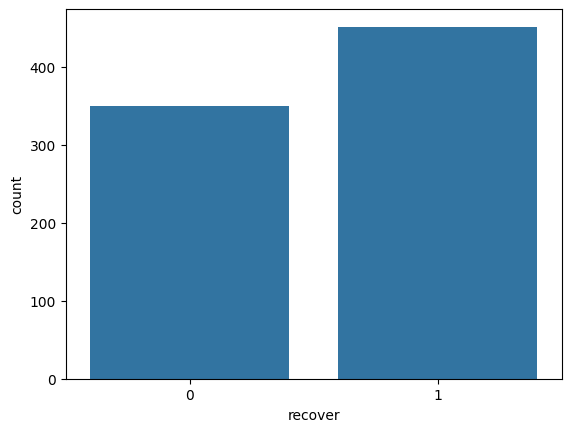

<function matplotlib.pyplot.show(close=None, block=None)>

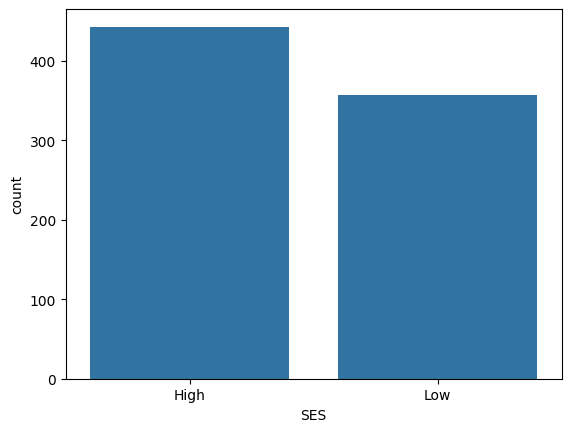

In [31]:
print(pd.crosstab(df["SES"], df["drug"]), '\n')
print(df.groupby("SES")["recover"].mean(), '\n')

print(df.groupby("drug")["recover"].mean(), '\n')
print(df.groupby(["SES", "drug"])["recover"].mean(), '\n')

print(df.groupby(["age", "drug"])["recover"].mean(), '\n')
print(df.groupby(["SES", "age", "drug"])["recover"].mean(), '\n')

print(pd.crosstab(df["age"], df["drug"]), '\n')

sns.countplot(x='recover', data=df)
plt.show()
sns.countplot(x='SES', data=df)
plt.show

## Correlations

Simple correlation analysis suggests a positive relationship between the drug and recovery. However, this association is misleading because it ignores the effect of confounding variables such as age.

Once the data are stratified by age, the direction of the relationship changes within each group, showing that correlation alone is not sufficient to identify causal effects in this dataset.

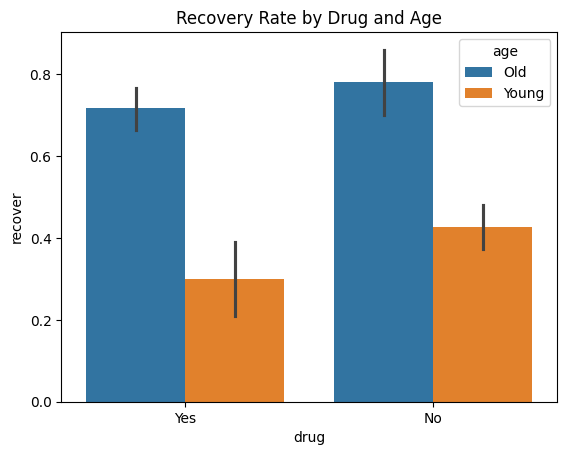

In [33]:
sns.barplot(
    data=df,
    x="drug",
    y="recover",
    hue="age"
)

plt.title("Recovery Rate by Drug and Age")
plt.show()

## Regression Analysis

The naive OLS model suggests that receiving the drug increases recovery probability by approximately 9.8%. However, this estimate does not account for confounding variables.

After controlling for age, SES, and hospital rating, the estimated effect of the drug becomes negative (-7.5%), indicating a decrease in recovery probability.

This sign reversal between the naive and controlled models provides strong evidence of Simpson’s paradox. The difference arises because the drug is disproportionately assigned to older patients, who also have higher baseline recovery rates, leading to biased estimates in the aggregated analysis.

In [16]:
import statsmodels.formula.api as smf

naive = smf.ols(
    "recover ~ drug",
    data=df
).fit()

print(naive.summary())

                            OLS Regression Results                            
Dep. Variable:                recover   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     7.787
Date:                Sun, 31 May 2026   Prob (F-statistic):            0.00539
Time:                        13:31:00   Log-Likelihood:                -570.19
No. Observations:                 800   AIC:                             1144.
Df Residuals:                     798   BIC:                             1154.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.5150      0.025     20.844      

In [17]:
controlled = smf.ols(
    "recover ~ drug + SES + age + hospital_rating",
    data=df
).fit()

print(controlled.summary())

                            OLS Regression Results                            
Dep. Variable:                recover   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     28.63
Date:                Sun, 31 May 2026   Prob (F-statistic):           3.01e-22
Time:                        13:31:19   Log-Likelihood:                -520.25
No. Observations:                 800   AIC:                             1051.
Df Residuals:                     795   BIC:                             1074.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.7385      0.286     